# Air Quality Index Prediction Using Machine Learning
# Objective
Predict air quality using environmental sensor measurements.

# Models Used
1. Linear Regression
2. Random Forest Regressor

# Evaluation Metrics
- MAE
- RMSE
- R² Score

In [48]:
import numpy as np
import pandas as pd
import matplotlib as pyplot
import seaborn as sns

In [49]:
# load dataset
df = pd.read_csv(r"C:\Users\Anmol\Downloads\air+quality\AirQualityUCI.csv")
df

Date;Time;CO(GT);PT08.S1(CO);NMHC(GT);C6H6(GT);PT08.S2(NMHC);NOx(GT);PT08.S3(NOx);NO2(GT);PT08.S4(NO2);PT08.S5(O3);T;RH;AH;;
10/03/2004;18.00.00;2            6;1360;150;11                 9;1046;166;1056;113;1692;1268;13 6;48 9;0                                                7578;;                                                                          
10/03/2004;19.00.00;2;1292;112;9 4;955;103;1174;92;1559;972;13 3;47                             7;0  7255;;                                                NaN                                                                          
10/03/2004;20.00.00;2            2;1402;88;9                   0;939;131;1140;114;1555;1074;11  9;54 0;0                                                7502;;                                                                          
10/03/2004;21.00.00;2            2;1376;80;9                   2;948;172;1092;122;1584;1203;11  0;60 0;0                                                7867;;                                                                          
10/03/2004;22.00.00;1            6;1272;51;6                   5;836;131;1205;116;1490;1110;11  2;59 6;0                                                7888;;                                                                          
...                                                                                                                                                        ...                                                                          
;;;;;;;;;;;;;;;;                 NaN                           NaN                              NaN  NaN                                                   NaN                                                                          
                                                                                                     NaN                                                   NaN                                                                          
                                                                                                     NaN                                                   NaN                                                                          
                                                                                                     NaN                                                   NaN                                                                          
                                                                                                     NaN                                                   NaN                                                                          

[9471 rows x 1 columns]

In [50]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Anmol\Downloads\air+quality\AirQualityUCI.csv", sep=';')

### DATA CLEANING AND VALUE HANDLING

In [51]:
# replace comma with dot in entire dataframe
df = df.replace(',', '.', regex=True)

# convert all columns to numeric (force conversion)
df = df.apply(pd.to_numeric, errors='coerce')

In [52]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = df.columns.str.strip()

In [53]:
print(df.columns)

Index(['Date', 'Time', 'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
       'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)',
       'PT08.S5(O3)', 'T', 'RH', 'AH'],
      dtype='object')


In [54]:
df.columns = df.columns.str.strip()

In [55]:
for col in df.columns:
    print(col)

Date
Time
CO(GT)
PT08.S1(CO)
NMHC(GT)
C6H6(GT)
PT08.S2(NMHC)
NOx(GT)
PT08.S3(NOx)
NO2(GT)
PT08.S4(NO2)
PT08.S5(O3)
T
RH
AH


In [56]:
print(df.head())

   Date  Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  \
0   NaN   NaN     2.6       1360.0     150.0      11.9         1046.0   
1   NaN   NaN     2.0       1292.0     112.0       9.4          955.0   
2   NaN   NaN     2.2       1402.0      88.0       9.0          939.0   
3   NaN   NaN     2.2       1376.0      80.0       9.2          948.0   
4   NaN   NaN     1.6       1272.0      51.0       6.5          836.0   

   NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH  \
0    166.0        1056.0    113.0        1692.0       1268.0  13.6  48.9   
1    103.0        1174.0     92.0        1559.0        972.0  13.3  47.7   
2    131.0        1140.0    114.0        1555.0       1074.0  11.9  54.0   
3    172.0        1092.0    122.0        1584.0       1203.0  11.0  60.0   
4    131.0        1205.0    116.0        1490.0       1110.0  11.2  59.6   

       AH  
0  0.7578  
1  0.7255  
2  0.7502  
3  0.7867  
4  0.7888  


In [57]:
# remove empty columns
df = df.dropna(axis=1, how='all')

# replace -200 (invalid values) with NaN
df = df.replace(-200, pd.NA)

# drop rows with missing values
df = df.dropna()

print(df.shape)

(827, 13)


### FEATURE SELECTION

In [58]:
# features (input)
X = df[['NOx(GT)', 'NO2(GT)', 'T', 'RH']]

# target (output)
y = df['CO(GT)']

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Random forest regressor

In [60]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
y_pred = model.predict(X_test)

In [62]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 0.26526908107372416
RMSE: 0.3853007587593442
R2 Score: 0.9286830510513921


In [63]:
#feature scaling and tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None]
}

grid = GridSearchCV(RandomForestRegressor(), param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': None, 'n_estimators': 200}


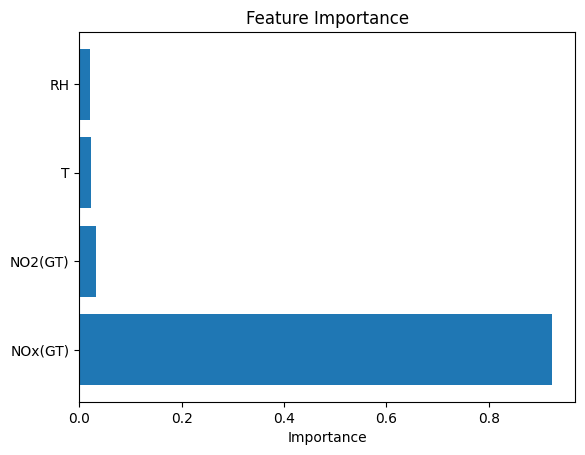

In [64]:
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

### LINEAR REGRESSION

### Defining Features (X) and Target (y)

In [65]:
# Define target
y = df['CO(GT)']

# Define features (everything except CO)
X = df.drop('CO(GT)', axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (827, 12)
y shape: (827,)


### Training Linear Regression Model

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (661, 12)
X_test: (166, 12)
y_train: (661,)
y_test: (166,)


### Feature Scaling

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data, transform both
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [68]:
from sklearn.linear_model import LinearRegression

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
y_pred = model.predict(X_test)

In [70]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

MSE: 0.057925294247378564
R2 Score: 0.9721733275987304


Since this is a regression problem, accuracy is not an appropriate metric. 
Instead, we evaluate performance using metrics like Mean Squared Error and R² score
which measure prediction error and variance explained by the model

In [71]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients.sort_values(by='Coefficient', ascending=False))

               Coefficient
C6H6(GT)          1.106391
NOx(GT)           0.349323
PT08.S1(CO)       0.347153
NMHC(GT)          0.194091
NO2(GT)           0.144975
AH                0.125356
PT08.S3(NOx)     -0.038650
RH               -0.129500
T                -0.204506
PT08.S5(O3)      -0.210786
PT08.S4(NO2)     -0.223367
PT08.S2(NMHC)    -0.299654


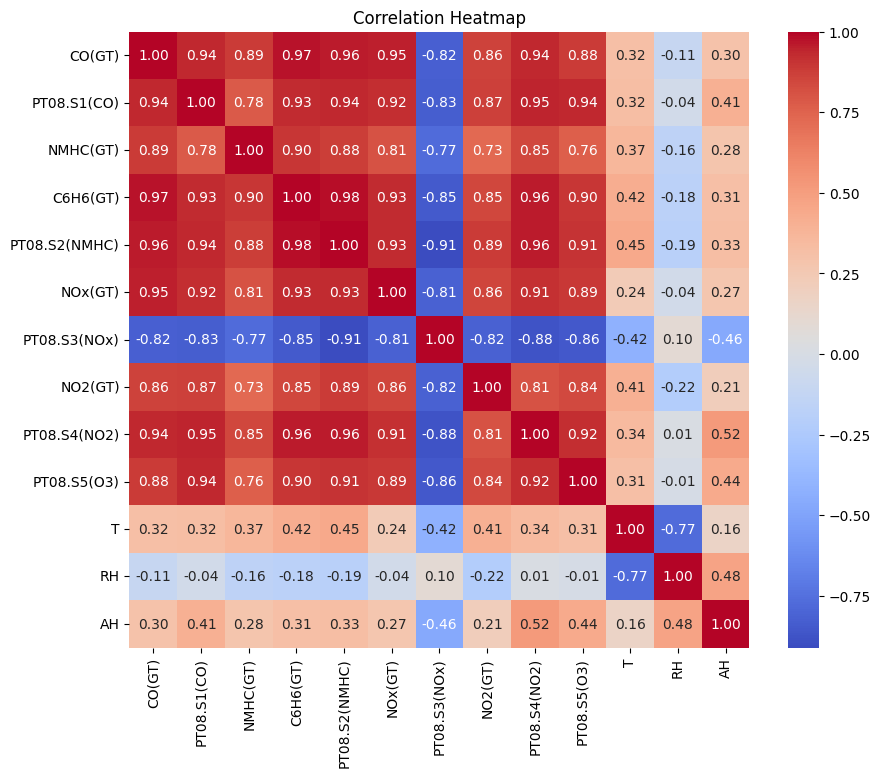

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

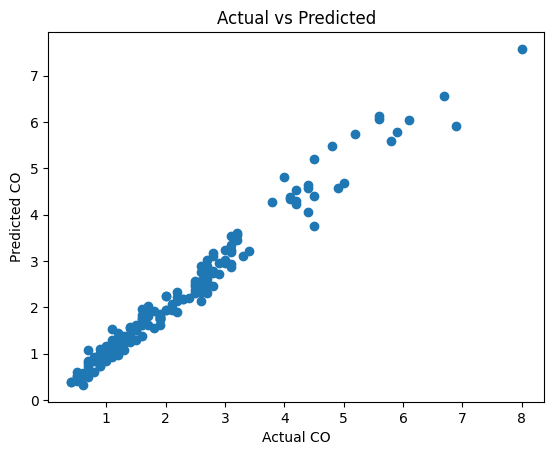

In [73]:
plt.figure()

plt.scatter(y_test, y_pred)
plt.xlabel("Actual CO")
plt.ylabel("Predicted CO")
plt.title("Actual vs Predicted")

plt.show()

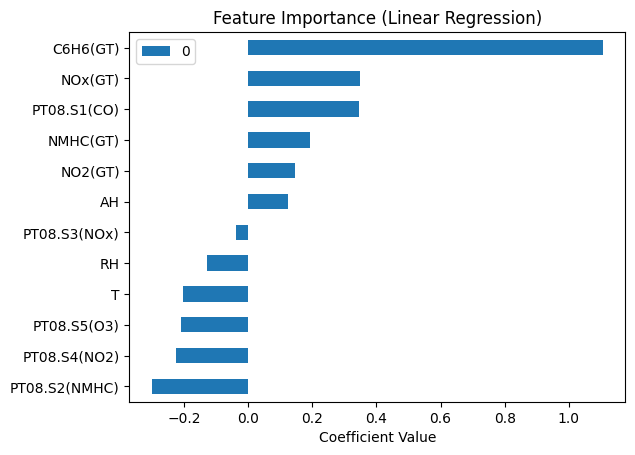

In [74]:
coefficients = pd.DataFrame(model.coef_, X.columns)

coefficients.sort_values(by=0).plot(kind='barh')

plt.title("Feature Importance (Linear Regression)")
plt.xlabel("Coefficient Value")

plt.show()

The feature importance plot shows that NOx and benzene have the highest positive influence on CO levels, while environmental factors like temperature and humidity show negative relationships

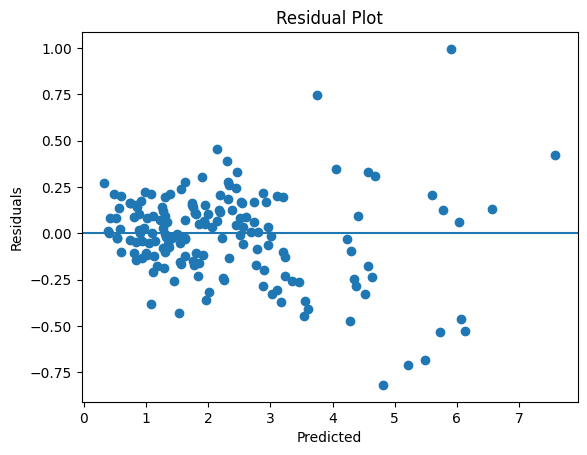

In [75]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.axhline(y=0)

plt.show()

The residual plot shows that errors are centered around zero, indicating a good fit. However, the spread increases at higher predicted values, suggesting heteroscedasticity and possible non-linear relationships